In [ ]:
# # !pip install pandas
# # !pip install seaborn
# # !pip freeze > requirements.txt
# !pip install -r requirements.txt

In [55]:
# Reading Train Data
import pandas as pd
df = pd.read_csv("Dataset/train.csv")
# df.columns
# len(df)


In [ ]:
for col in df.columns:
    print(col, df[col].unique()) if df[col].dtype == 'object' else None

In [56]:
# null Handling
df.isnull().sum()

id                           0
Age                      18705
Gender                       0
Annual Income            44949
Marital Status           18529
Number of Dependents    109672
Education Level              0
Occupation              358075
Health Score             74076
Location                     0
Policy Type                  0
Previous Claims         364029
Vehicle Age                  6
Credit Score            137882
Insurance Duration           1
Policy Start Date            0
Customer Feedback        77824
Smoking Status               0
Exercise Frequency           0
Property Type                0
Premium Amount               0
dtype: int64

In [57]:
# Age Handling
# Had idea to use Education qualification to fill the nulls in Age column
# But given data doesn't resonate with that idea as there are people with phd and age 18

# So grouping by Education level and filling nulls with median of that group
df["Age"] = df.groupby(
                        "Education Level"
                    )["Age"].transform(lambda x: x.fillna(x.median()))
df["Annual Income"] = df.groupby([
                                    "Education Level", 
                                    "Location",
                                    "Property Type"
                                ])["Annual Income"].transform(lambda x: x.fillna(x.median()))
df["Marital Status"] = df.groupby(
                                    pd.cut(df["Age"], [17, 25, 35, 50, 70, 100])
                                )["Marital Status"].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown"))

df["Number of Dependents"] = df.groupby([
                                            "Gender", 
                                            pd.cut(df["Age"], [17, 25, 35, 50, 70, 100]), 
                                            pd.qcut(df["Annual Income"], 5, duplicates="drop"), 
                                            "Marital Status"
                                        ])["Number of Dependents"].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown"))

df["Occupation"] = df.groupby([
                                "Gender", 
                                pd.cut(df["Age"], [17, 25, 35, 50, 70, 100]), 
                                pd.qcut(df["Annual Income"], 5, duplicates="drop"), 
                                "Marital Status",
                                "Education Level",
                                "Location",
                                "Property Type"
                            ])["Occupation"].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown"))

df["Health Score"] = df.groupby([
                                    "Gender", 
                                    pd.cut(df["Age"], [17, 25, 35, 50, 70, 100]), 
                                    "Smoking Status",
                                ])["Health Score"].transform(lambda x: x.fillna(x.median()))
df["Previous Claims"] = df.groupby([
                                    pd.cut(df["Age"], [17, 25, 35, 50, 70, 100]), 
                                    "Smoking Status",
                                    pd.qcut(df["Annual Income"], 5, duplicates="drop"),
                                    "Occupation",
                                    "Policy Type",
                                ])["Previous Claims"].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown"))
df["Vehicle Age"] = df.groupby([
                                    pd.cut(df["Age"], [17, 25, 35, 50, 70, 100]), 
                                    pd.qcut(df["Annual Income"], 5, duplicates="drop"),
                                    "Location",
                                    "Property Type",
                                ])["Vehicle Age"].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown"))
df["Credit Score"] = df.groupby([
                                    pd.cut(df["Age"], [17, 25, 35, 50, 70, 100]), 
                                    pd.qcut(df["Annual Income"], 5, duplicates="drop"),
                                    "Policy Type",
                                ])["Credit Score"].transform(lambda x: x.fillna(x.median()))

df["Insurance Duration"].fillna(df["Insurance Duration"].median(), inplace=True)

df["Customer Feedback"] = df.groupby([
                                    pd.cut(df["Age"], [17, 25, 35, 50, 70, 100]), 
                                    "Education Level",
                                    "Location",
                                    pd.qcut(df["Annual Income"], 5, duplicates="drop"),
                                    "Policy Type",
                                ])["Customer Feedback"].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown"))


# print(df[df["id"]==18])
# print(df[df["id"]==36])
df.isnull().sum()

C:\Users\nirma\AppData\Local\Temp\ipykernel_41160\932267525.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["Marital Status"] = df.groupby(
C:\Users\nirma\AppData\Local\Temp\ipykernel_41160\932267525.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["Number of Dependents"] = df.groupby([
C:\Users\nirma\AppData\Local\Temp\ipykernel_41160\932267525.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["Occu

id                      0
Age                     0
Gender                  0
Annual Income           0
Marital Status          0
Number of Dependents    0
Education Level         0
Occupation              0
Health Score            0
Location                0
Policy Type             0
Previous Claims         0
Vehicle Age             0
Credit Score            0
Insurance Duration      0
Policy Start Date       0
Customer Feedback       0
Smoking Status          0
Exercise Frequency      0
Property Type           0
Premium Amount          0
dtype: int64

In [58]:
df.duplicated().sum()

np.int64(0)

In [38]:
date = pd.to_datetime(df["Policy Start Date"], format="%Y-%m-%d %H:%M:%S.%f")
df["Policy_start_year"] = date.dt.year
df["Policy_start_month"] = date.dt.month
df["Policy_start_day"] = date.dt.day
df.drop(columns=["Policy Start Date"], inplace=True)

In [59]:
df.set_index("id", inplace=True)

In [ ]:
for col in df.columns:
    print(col, df[col].unique()) if df[col].dtype == 'object' else None
for col in df.columns:
    print(col, df[col].unique())

In [ ]:
df.head()

In [60]:
from sklearn.preprocessing import LabelEncoder
enc = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = enc.fit_transform(df[col])

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1200000 entries, 0 to 1199999
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   Age                   1200000 non-null  float64
 1   Gender                1200000 non-null  int64  
 2   Annual Income         1200000 non-null  float64
 3   Marital Status        1200000 non-null  int64  
 4   Number of Dependents  1200000 non-null  float64
 5   Education Level       1200000 non-null  int64  
 6   Occupation            1200000 non-null  int64  
 7   Health Score          1200000 non-null  float64
 8   Location              1200000 non-null  int64  
 9   Policy Type           1200000 non-null  int64  
 10  Previous Claims       1200000 non-null  float64
 11  Vehicle Age           1200000 non-null  float64
 12  Credit Score          1200000 non-null  float64
 13  Insurance Duration    1200000 non-null  float64
 14  Policy Start Date     1200000 non-null 

In [62]:
coor_data=df.corr()
# coor_data.to_csv("correlation_data.csv")

<Axes: >

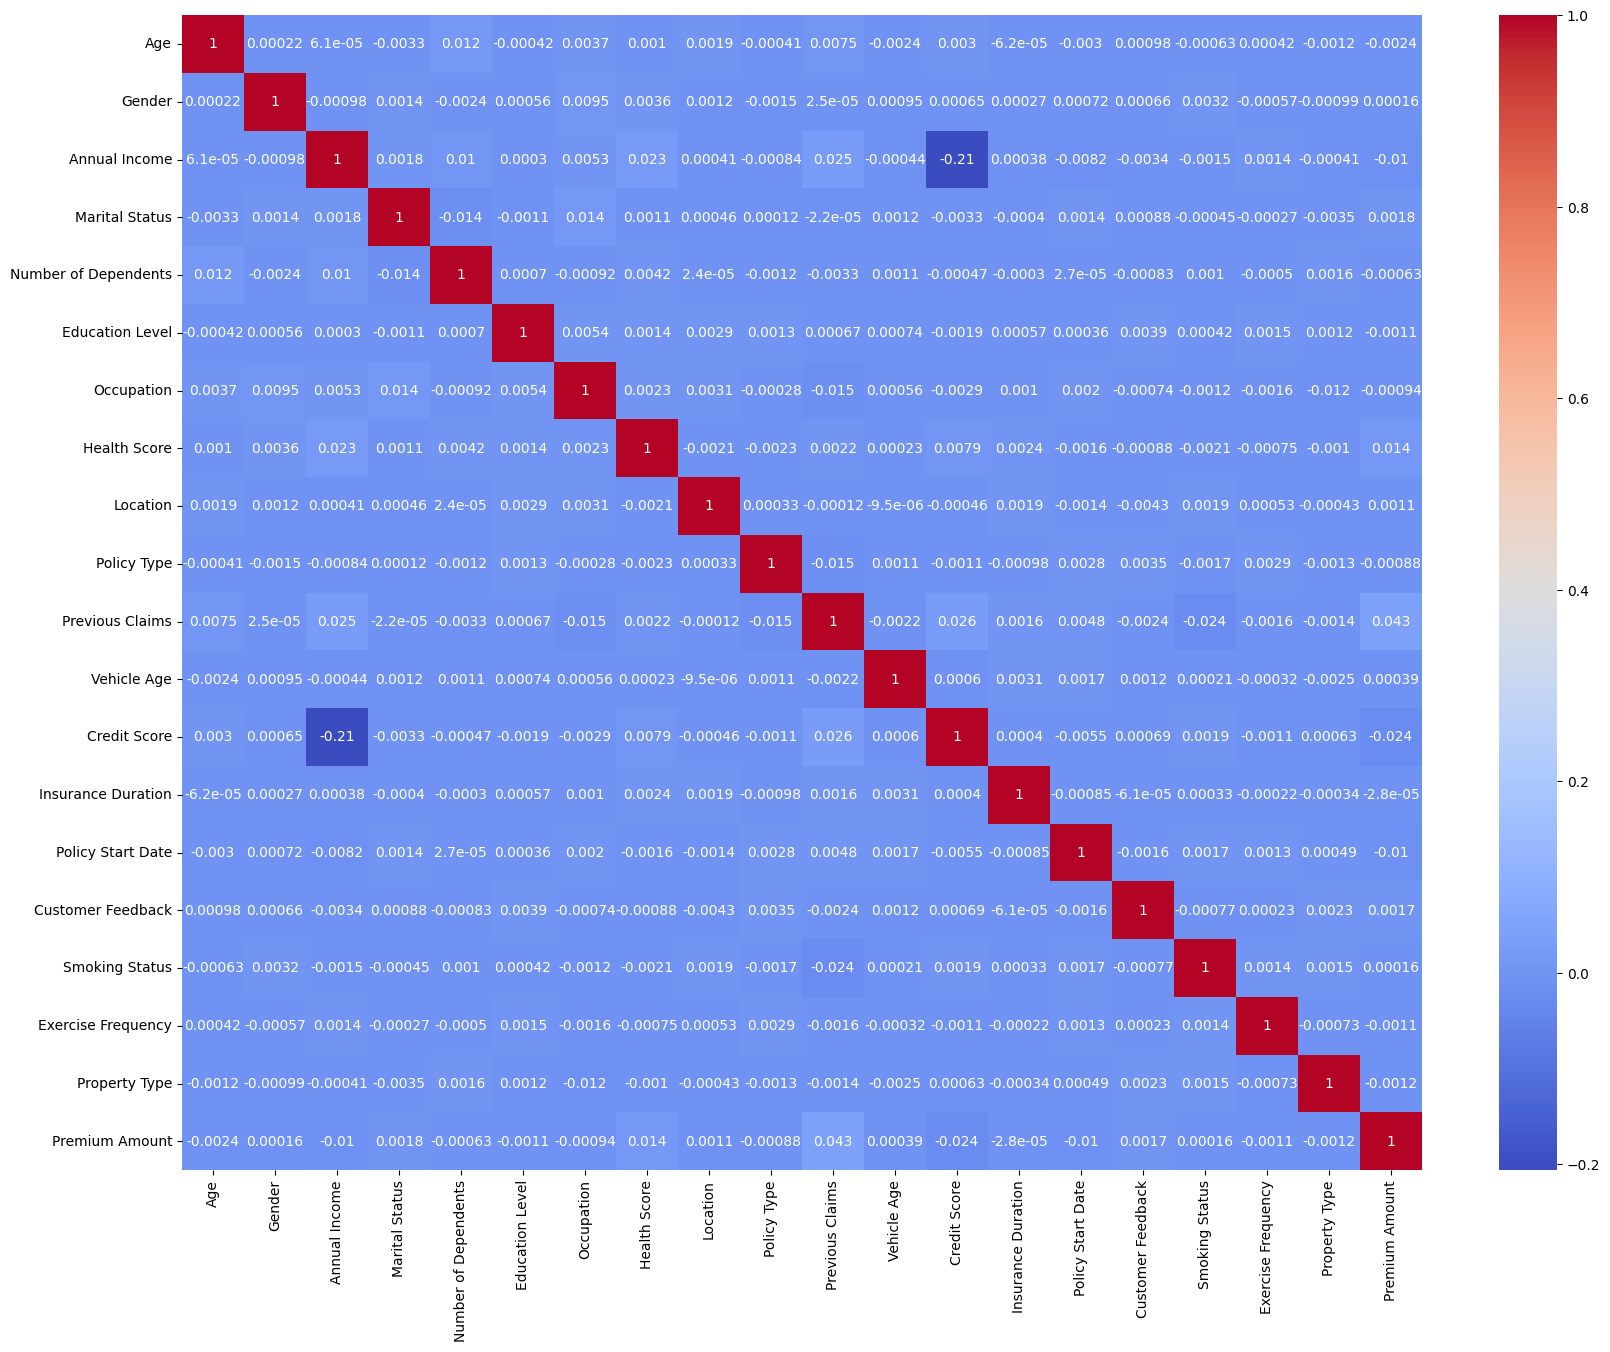

In [63]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 15))
import seaborn as sns
sns.heatmap(coor_data, annot=True, cmap="coolwarm")

In [64]:
pd.set_option("display.max_columns",None)
df.head()

,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
id,,,,,,,,,,,,,,,,,,,,
0,19.0,0,10049.0,1,1.0,0,1,22.598761,2,2,2.0,17.0,372.0,5.0,145522,2,0,3,2,2869.0
1,39.0,0,31678.0,0,3.0,2,0,15.569731,0,1,1.0,12.0,694.0,2.0,127832,0,1,1,2,1483.0
2,23.0,1,25602.0,0,3.0,1,1,47.177549,1,2,1.0,14.0,615.0,3.0,137880,1,1,3,2,567.0
3,21.0,1,141855.0,1,2.0,0,0,10.938144,0,0,1.0,0.0,367.0,1.0,161517,2,1,0,0,765.0
4,21.0,1,39651.0,2,1.0,0,1,20.376094,0,2,0.0,8.0,598.0,4.0,76621,2,1,3,2,2022.0


In [65]:
for col in df.columns:
    print(col, df[col].unique())

Age [19. 39. 23. 21. 29. 41. 48. 44. 56. 25. 40. 18. 59. 34. 22. 46. 49. 42.
 43. 64. 52. 37. 58. 50. 35. 61. 31. 54. 45. 30. 33. 28. 62. 53. 47. 27.
 38. 63. 32. 36. 20. 51. 55. 57. 24. 60. 26.]
Gender [0 1]
Annual Income [ 10049.  31678.  25602. ... 125361. 137940.  40368.]
Marital Status [1 0 2]
Number of Dependents [1. 3. 2. 0. 4.]
Education Level [0 2 1 3]
Occupation [1 0 2]
Health Score [22.59876067 15.56973099 47.17754929 ... 47.09690866 13.6616783
 11.48348225]
Location [2 0 1]
Policy Type [2 1 0]
Previous Claims [2. 1. 0. 3. 4. 5. 6. 7. 8. 9.]
Vehicle Age [17. 12. 14.  0.  8.  4. 11. 10.  9.  6. 19.  3. 15. 16.  5.  7. 18.  1.
  2. 13.]
Credit Score [372.  694.  615.  367.  598.  614.  807.  398.  685.  635.  431.  597.
 613.  511.  498.  584.  609.  626.  420.  595.  799.  773.  798.  543.
 416.  425.  486.  795.  495.  449.  596.  803.  421.  695.  713.  589.
 476.  812.  382.  469.  636.  530.  538.  842.  575.  794.  836.  784.
 439.  381.  801.  593.  624.  497.  359.  66

In [66]:
continues=["Age", "Annual Income", "Health Score", "Credit Score","Policy_start_year", "Policy_start_month", "Policy_start_day", "Premium Amount"]
categories = ["Gender", "Marital Status",	"Number of Dependents",	"Education Level", "Occupation", "Location", "Policy Type",	"Previous Claims", "Vehicle Age", "Insurance Duration",	"Customer Feedback", "Smoking Status", "Exercise Frequency", "Property Type"]

In [67]:
# Hypothesis Testing
import scipy.stats as stats

#continious vs continious
def two_sample(d1,d2):
    t=0
    f=0
    for i in range(31):
        sample1 = d1.sample(frac=0.03)
        sample2 = d2.sample(frac=0.03)
        t_test,p_value = stats.ttest_ind(sample1,sample2)
        if p_value < 0.05:
            f+=1
        else:
            t+=1
    if t>f:
        return True
    else:
        return False
    
#cat vs cat
def chisquare_test(d1,d2):
    return True if stats.chi2_contingency(pd.crosstab(d1,d2))[1]<0.05 else False

#continious(d1) vs cat(d2)
def annova_test(d1,d2):
    group = df[d2].unique()
    data={}
    for i in group:
        data[i]= df[d1][df[d2]==i]
    fvalue,p_value = stats.f_oneway(*[i for i in data.values()])
    return True if p_value>0.05 else False

In [68]:
# Hypothesis Testing
final = {}
for i in df.columns:
    final[i] = {}
    for j in df.columns:
        if (i in continues) and (j in continues):
            result = two_sample(df[i],df[j])
        elif (i in categories) and (j in categories):
            result = chisquare_test(df[i],df[j])
        elif (i in continues) and (j in categories):
            result = annova_test(i,j)
        elif (i in categories) and (j in continues):
            result = annova_test(j,i)
        if result:
            final[i][j] = 1
        else:
            final[i][j] = 0

In [69]:
final = pd.DataFrame(final)
final

,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
Age,1,1,0,0,0,1,0,0,0,1,0,1,0,1,0,0,1,1,1,0
Gender,1,1,1,1,1,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1
Annual Income,0,1,1,1,0,0,0,0,1,1,0,1,0,1,0,0,1,0,1,0
Marital Status,0,1,1,1,1,0,1,1,0,0,0,0,0,1,0,0,0,0,1,1
Number of Dependents,0,1,0,1,1,0,1,0,0,0,1,1,1,0,0,0,0,1,1,1
Education Level,1,0,0,0,0,1,1,0,1,1,0,0,0,1,0,1,0,1,1,1
Occupation,0,1,0,1,1,1,1,0,1,0,1,0,0,1,0,0,0,0,1,1
Health Score,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,1,0,0
Location,0,0,1,0,0,1,1,0,1,0,0,0,1,1,0,1,0,0,0,1
Policy Type,1,0,1,0,0,1,0,0,0,1,1,0,1,0,0,1,0,1,0,1


<Axes: >

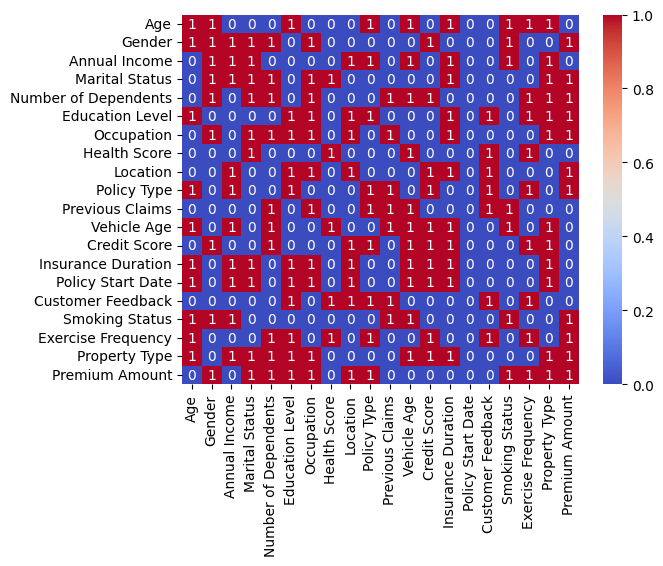

In [70]:
sns.heatmap(final, annot=True, cmap="coolwarm")

In [72]:
df.columns

Index(['Age', 'Gender', 'Annual Income', 'Marital Status',
       'Number of Dependents', 'Education Level', 'Occupation', 'Health Score',
       'Location', 'Policy Type', 'Previous Claims', 'Vehicle Age',
       'Credit Score', 'Insurance Duration', 'Policy Start Date',
       'Customer Feedback', 'Smoking Status', 'Exercise Frequency',
       'Property Type', 'Premium Amount'],
      dtype='object')

<Axes: xlabel='Gender', ylabel='Density'>

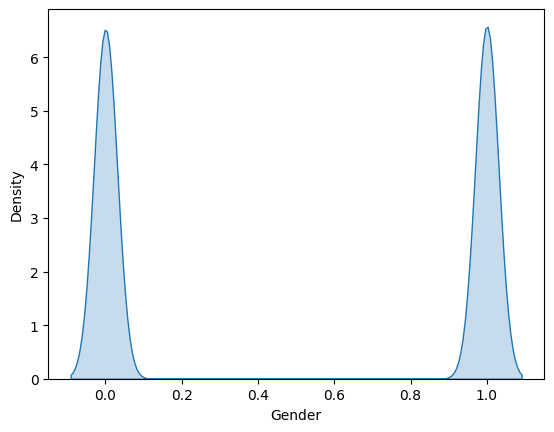

In [73]:
# sns.distplot(df["Annual Income", "Age"])
# sns.kdeplot(df["Age"], label="Age", fill=True)
sns.kdeplot(df["Gender"], label="Age", fill=True)
# sns.kdeplot(df["Credit Score"], label="Age", fill=True)

In [ ]:
# identify skew df["col"].skew() -> flow in x axis
# case1 - output between -0.5 to 0.5 - less skewness , no transformation is required
# case 2 - output in between -1 to -0.5 or 0.5 to 1 - mild skew , transformation is can be considered
# case 3 - output in  <-1 or 1 < - strong skew , transformation is required

# identify skew df["col"].kurtosis() -> flow in y axis
# case1 - output between -3 to 3 - less kurtosis , no transformation is required
# case 2 - output in between -6 to -3 or 3 to 6 - mild kurtosis , transformation is can be considered
# case 3 - output in  <-6 or 6 < - strong kurtosis , transformation is required

In [74]:
for i in df.columns:
    if i in continues:
        print(i,df[i].skew(),df[i].kurtosis())

Age -0.012124039077023415 -1.1663719030495083
Annual Income 1.5229156031092268 2.0168632888944953
Health Score 0.3073046329658737 -0.6349277358406007
Credit Score -0.14254054982621336 -0.8948265290786672
Premium Amount 1.2409154932891029 1.5185855747992734


In [ ]:
# Boxcox = -2, -1, -0.5, 0, 0.5, 1, 2 

In [75]:
Boxcox = [-2, -1, -0.5, 0, 0.5, 1, 2 ]
for i in Boxcox:
    df["Annual Income New"]=stats.boxcox(df["Annual Income"], lmbda=i)
    print(i,"Annual Income New",df["Annual Income New"].skew(),df["Annual Income New"].kurtosis())

-2 Annual Income New -663.4684192192561 546617.5877377162
-1 Annual Income New -113.46015165507202 30085.741125898003
-0.5 Annual Income New -9.854853113213325 202.19102932860213
0 Annual Income New -1.0495980636757716 1.4553740434515086
0.5 Annual Income New 0.49710591533150594 -0.25852025454526295
1 Annual Income New 1.5229156031092275 2.016863288894496
2 Annual Income New 2.9347953889676837 8.945025013195027


In [76]:
df["Annual Income"]=stats.boxcox(df["Annual Income"], lmbda=0.5)

In [77]:
df.columns

Index(['Age', 'Gender', 'Annual Income', 'Marital Status',
       'Number of Dependents', 'Education Level', 'Occupation', 'Health Score',
       'Location', 'Policy Type', 'Previous Claims', 'Vehicle Age',
       'Credit Score', 'Insurance Duration', 'Policy Start Date',
       'Customer Feedback', 'Smoking Status', 'Exercise Frequency',
       'Property Type', 'Premium Amount', 'Annual Income New'],
      dtype='object')

In [78]:
df.drop(columns=["Annual Income New"], inplace=True ,axis=1)